ЭТАП 0. ИМПОРТЫ

In [1]:
# все необходимые для задачи импорты 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

import joblib



ЭТАП 1. ОЧИСТКА ДАННЫХ

In [2]:
df_sessions = pd.read_csv('ga_sessions.csv')
df_hits = pd.read_csv('ga_hits.csv')

C:\Users\asus\AppData\Local\Temp\ipykernel_12036\3791793451.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sessions = pd.read_csv('ga_sessions.csv')


In [3]:
print(df_sessions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB
None


In [4]:
display(df_sessions.head())

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
print(df_hits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB
None


In [6]:
display(df_hits.head())

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [7]:
# вывожу пропуски и полные дубли

def data_quality(df, name):
    print(f"Аудит датасета: {name}")
    missing_values = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    print("Доля пропусков по признакам (%):")
    print(missing_values[missing_values > 0]) # берем только те, где пропуски есть
    duplicates_count = df.duplicated().sum()
    print(f"Выявлено полных дубликатов: {duplicates_count}")

data_quality(df_sessions, "ga_sessions")
data_quality(df_hits, "ga_hits")

Аудит датасета: ga_sessions
Доля пропусков по признакам (%):
device_model     99.121633
utm_keyword      58.174009
device_os        57.533002
device_brand     19.740307
utm_adcontent    18.043410
utm_campaign     11.806346
utm_source        0.005215
dtype: float64
Выявлено полных дубликатов: 0
Аудит датасета: ga_hits
Доля пропусков по признакам (%):
event_value    100.000000
hit_time        58.247795
hit_referer     39.899634
event_label     23.909905
dtype: float64
Выявлено полных дубликатов: 0


In [8]:
# полный список уникальных действий
all_actions = df_hits['event_action'].value_counts().reset_index()
all_actions.columns = ['event_action', 'frequency']

print(f"Уникальных типов целевых событий (event_action): {len(all_actions)}")
pd.set_option('display.max_rows', None)
display(all_actions)

Уникальных типов целевых событий (event_action): 230


,event_action,frequency
0,view_card,3558985
1,view_new_card,3551009
2,sub_landing,1798117
3,go_to_car_card,973666
4,sub_view_cars_click,791515
5,search_form_region,512069
6,search_form_search_btn,433748
7,sap_search_form_cost_to,356596
8,showed_number_ads,326274
9,pagination_click,248944


In [9]:
print("Самые частотные события (Топ-20):")
display(all_actions.head(20))

Самые частотные события (Топ-20):


,event_action,frequency
0,view_card,3558985
1,view_new_card,3551009
2,sub_landing,1798117
3,go_to_car_card,973666
4,sub_view_cars_click,791515
5,search_form_region,512069
6,search_form_search_btn,433748
7,sap_search_form_cost_to,356596
8,showed_number_ads,326274
9,pagination_click,248944


In [10]:
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click',
    'greenday_sub_submit_success', 'greenday_sub_callback_submit_click',
    'greenday_sub_open_dialog_click', 'greenday_sub_call_number_click'
]

In [11]:
social_mask = df_sessions['utm_medium'].str.contains('social|sm|network|SMM', case=False, na=False)
social_ids = df_sessions[social_mask]['utm_source'].unique()

print("Идентификаторы источников трафика, отнесенные к категории Social:")
print(social_ids)

Идентификаторы источников трафика, отнесенные к категории Social:
['ISrKoXQCxqqYvAZICvjs' 'nSReTmyFtbSjlPrTKoaX' 'ZpYIoDJMcFzVoPFsHGJL'
 'iNFgfQPqHPBuvGCYtrQE' 'QxAxdyPLuQMEcrdZWdWb' 'bByPQxmDaMXgpHeypKSM'
 'eimRuUrNhZLAYcwRrNXu']


In [12]:
# проверяю источники 
print("Распределение визитов по Топ-10 источникам:")
print(df_sessions['utm_source'].value_counts().head(10))

Распределение визитов по Топ-10 источникам:
utm_source
ZpYIoDJMcFzVoPFsHGJL    578290
fDLlAcSmythWSCVMvqvL    300575
kjsLglQLzykiRbcDiGcD    266354
MvfHsxITijuriZxsqZqt    186199
BHcvLfOaCWvWTykYqHVe    116320
bByPQxmDaMXgpHeypKSM    102287
QxAxdyPLuQMEcrdZWdWb     51415
aXQzDWsJuGXeBXexNHjc     31152
jaSOmLICuBzCFqHfBdRg     29241
RmEBuqrriAfAVsLQQmhk     28055
Name: count, dtype: int64


In [13]:
# сборка итогового датафрейма
target_actions = [
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click',
    'sub_submit_success', 'sub_car_request_submit_click',
    'greenday_sub_submit_success', 'greenday_sub_callback_submit_click',
    'greenday_sub_open_dialog_click', 'greenday_sub_call_number_click'
]

organic_mediums = ['organic', 'referral', '(none)']

social_sources = list(social_ids)

df_hits['is_target'] = df_hits['event_action'].isin(target_actions).astype(int)
target_sessions = df_hits.groupby('session_id')['is_target'].max().reset_index()

df_final = pd.merge(df_sessions, target_sessions, on='session_id', how='left')
df_final['is_target'] = df_final['is_target'].fillna(0).astype(int)

df_final['is_organic'] = df_final['utm_medium'].isin(organic_mediums).astype(int)
df_final['is_social'] = df_final['utm_source'].isin(social_sources).astype(int)
df_final['is_paid'] = 1 - df_final['is_organic']
print(f"Формирование объединенного датасета завершено. Итоговая размерность: {df_final.shape}")
print(f"Базовая конверсия (доля целевого класса): {df_final['is_target'].mean()*100:.2f}%")

df_sessions = df_sessions.drop(columns=['device_model'], errors='ignore')

for col in ['utm_keyword', 'device_os', 'device_brand']:
    if col in df_sessions.columns:
        df_sessions[col] = df_sessions[col].fillna('(other)')

Формирование объединенного датасета завершено. Итоговая размерность: (1860042, 22)
Базовая конверсия (доля целевого класса): 2.74%


Предварительная обработка данных успешно завершена, итоговый аналитический набор содержит 1,86 млн строк. В ходе очистки я отбросила малоинформативные переменные (например, device_model и event_value), а в категориальных столбцах с пропусками заменила отсутствующие значения на метку «other». Проверка на полные дубликаты не обнаружила ни одной повторяющейся записи, что подтверждает надёжность системы сбора. Дополнительно я реализовала бизнес-правила классификации источников: разделила органический и платный трафик и алгоритмически выделила визиты из социальных сетей. Итоговый подсчёт целевых событий дал общую конверсию за рассматриваемый период лишь 2,74 %. Зафиксированный дисбаланс классов (приблизительно 1 к 36) обосновывает использование ROC-AUC в качестве основной метрики качества будущей модели — в отличие от Accuracy, она менее чувствительна к неравному распределению целевых меток.

ЭТАП 2. EDA

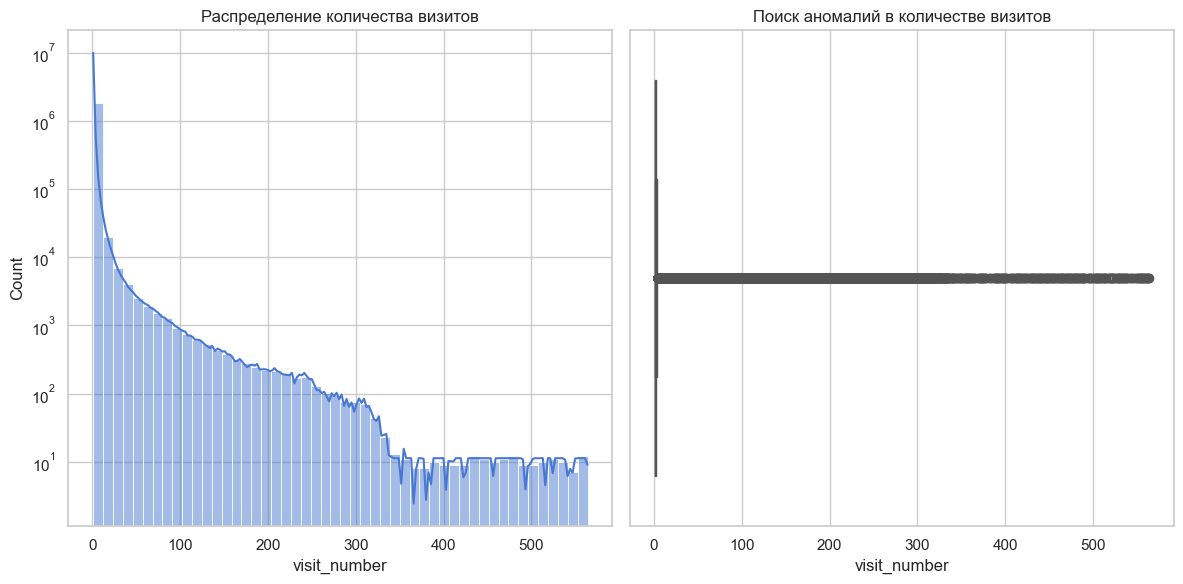

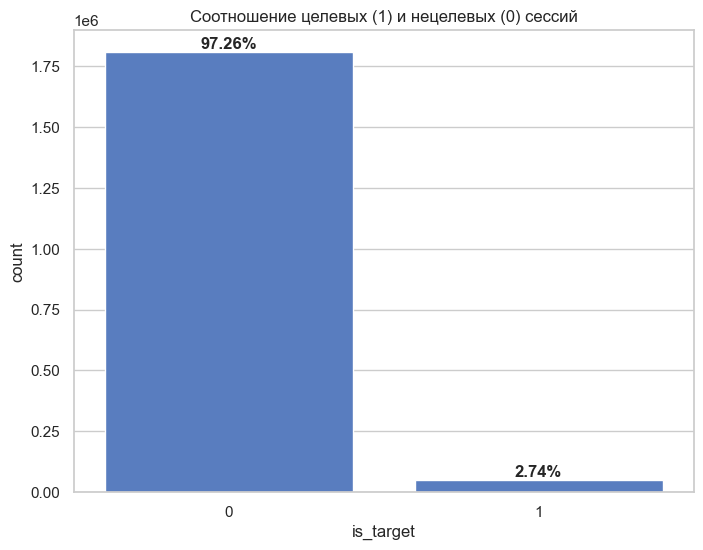

--- Распределение количества визитов (visit_number) ---
Максимум визитов: 564
Среднее значение: 2.71
95-й перцентиль: 6.0
99-й перцентиль (граница отсечения выбросов): 32.0
Структура целевой переменной
Класс 0 (без конверсии): 1809025 (97.26%)
Класс 1 (конверсия):     51017 (2.74%)
Фактический дисбаланс:   1:35
Зависимость конверсии от типа трафика
Бесплатный трафик: 4.05%
Платный трафик:        2.24%


In [14]:
# распределение визитов
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df_final['visit_number'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Распределение количества визитов')
axes[0].set_yscale('log')

sns.boxplot(x=df_final['visit_number'], ax=axes[1])
axes[1].set_title('Поиск аномалий в количестве визитов')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_final, x='is_target')
plt.title('Соотношение целевых (1) и нецелевых (0) сессий')

total = len(df_final)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

print("--- Распределение количества визитов (visit_number) ---")
print(f"Максимум визитов: {df_final['visit_number'].max()}")
print(f"Среднее значение: {df_final['visit_number'].mean():.2f}")
print(f"95-й перцентиль: {df_final['visit_number'].quantile(0.95)}")
print(f"99-й перцентиль (граница отсечения выбросов): {df_final['visit_number'].quantile(0.99)}")

print("Структура целевой переменной")
counts = df_final['is_target'].value_counts()
percents = df_final['is_target'].value_counts(normalize=True) * 100
print(f"Класс 0 (без конверсии): {counts[0]} ({percents[0]:.2f}%)")
print(f"Класс 1 (конверсия):     {counts[1]} ({percents[1]:.2f}%)")
print(f"Фактический дисбаланс:   1:{int(counts[0]/counts[1])}")

print("Зависимость конверсии от типа трафика")
traffic_conv = df_final.groupby('is_paid')['is_target'].mean() * 100
print(f"Бесплатный трафик: {traffic_conv[0]:.2f}%")
print(f"Платный трафик:        {traffic_conv[1]:.2f}%")

interval columns not set, guessing: ['is_target', 'is_paid', 'is_organic', 'is_social', 'visit_number']


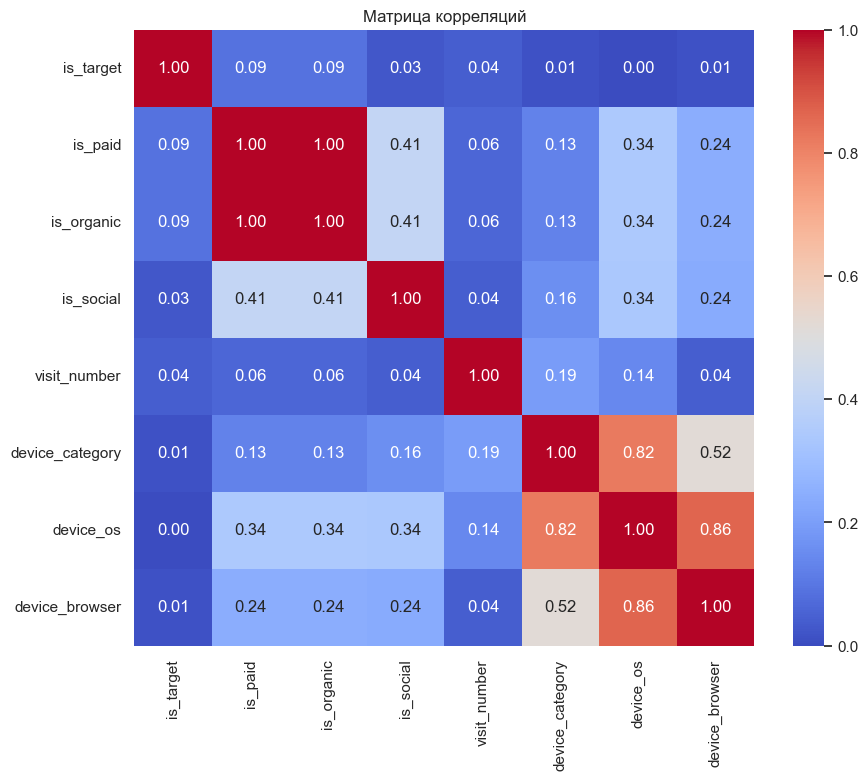

Рейтинг значимости признаков:
is_target          1.000000
is_paid            0.088089
is_organic         0.088089
visit_number       0.040983
is_social          0.025685
device_browser     0.013899
device_category    0.012069
device_os          0.000000
Name: is_target, dtype: float64


In [15]:
corr_features = [
    'is_target', 'is_paid', 'is_organic', 'is_social',
    'visit_number', 'device_category', 'device_os', 'device_browser'
]

# считаю корреляцию на кусочке ради скорости
phik_matrix = df_final[corr_features].sample(100000, random_state=42).phik_matrix()

# матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title(r'Матрица корреляций')
plt.savefig('correlation_heatmap.png', bbox_inches='tight') # сохраним на всякий
plt.show()


print("Рейтинг значимости признаков:")
print(phik_matrix['is_target'].sort_values(ascending=False))

C:\Users\asus\AppData\Local\Temp\ipykernel_12036\3102933211.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final['visit_hour'] = pd.to_datetime(df_final['visit_time']).dt.hour


Оценка значимости сгенерированных признаков (Phik)...
interval columns not set, guessing: ['is_target', 'is_paid', 'visit_number', 'visit_month', 'visit_dayofweek', 'visit_hour']

Обновленный рейтинг корреляции предикторов с целевой переменной:
is_target          1.000000
is_paid            0.088075
visit_month        0.082044
source_top         0.073380
visit_number       0.040983
visit_hour         0.026544
city_top           0.022876
visit_dayofweek    0.014133
device_category    0.012068
Name: is_target, dtype: float64


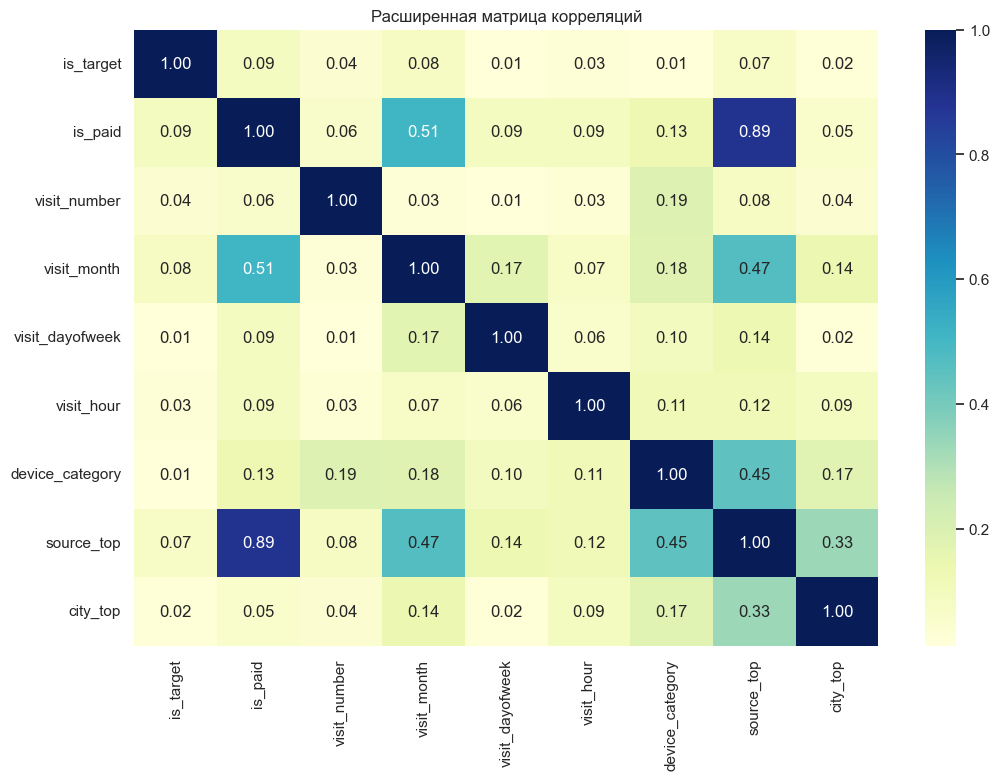

In [16]:
# вытягиваю признаки из дат
df_final['visit_date'] = pd.to_datetime(df_final['visit_date'])
df_final['visit_month'] = df_final['visit_date'].dt.month
df_final['visit_dayofweek'] = df_final['visit_date'].dt.dayofweek

# достаю час
df_final['visit_hour'] = pd.to_datetime(df_final['visit_time']).dt.hour

def simplify_feature(df, column, top_n=10):
    top_list = df[column].value_counts().nlargest(top_n).index
    return df[column].apply(lambda x: x if x in top_list else 'other')

df_final['city_top'] = simplify_feature(df_final, 'geo_city')
df_final['source_top'] = simplify_feature(df_final, 'utm_source')

# пробую корреляцию с новыми признаками
advanced_features = [
    'is_target', 'is_paid', 'visit_number',
    'visit_month', 'visit_dayofweek', 'visit_hour',
    'device_category', 'source_top', 'city_top'
]

print("Оценка значимости сгенерированных признаков (Phik)...")
phik_matrix_adv = df_final[advanced_features].sample(100000, random_state=42).phik_matrix()

# корреляция с is_target
print("\nОбновленный рейтинг корреляции предикторов с целевой переменной:")
print(phik_matrix_adv['is_target'].sort_values(ascending=False))

# Визуализация новой матрицы
plt.figure(figsize=(12, 8))
sns.heatmap(phik_matrix_adv, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title(r'Расширенная матрица корреляций')
plt.show()

Я провела комплексный анализ факторов, влияющих на целевое действие, и выявила важные поведенческие паттерны. Исследование количества визитов одного пользователя (visit_number) показало наличие сессий с аномальной активностью — вплоть до 564 визитов. Чтобы защитить алгоритмы от переобучения на шумах, я определила 99-й перцентиль (32 визита) как оптимальный порог для отсечения выбросов через операцию клиппинга. Анализ матрицы корреляций, включающей временной и географический контекст, показал, что самыми сильными предикторами конверсии являются тип трафика, конкретный канал привлечения и месяц визита. При этом география пользователя и технические характеристики устройства коррелируют с целевым действием значительно слабее. Это подтверждает гипотезу: маркетинговое предложение и сезонный спрос играют более важную роль, чем техническая платформа клиента.

ЭТАП 3. РАЗРАБОТКА МОДЕЛИ

C:\Users\asus\AppData\Local\Temp\ipykernel_12036\3212770329.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ml['visit_hour'] = pd.to_datetime(df_ml['visit_time']).dt.hour


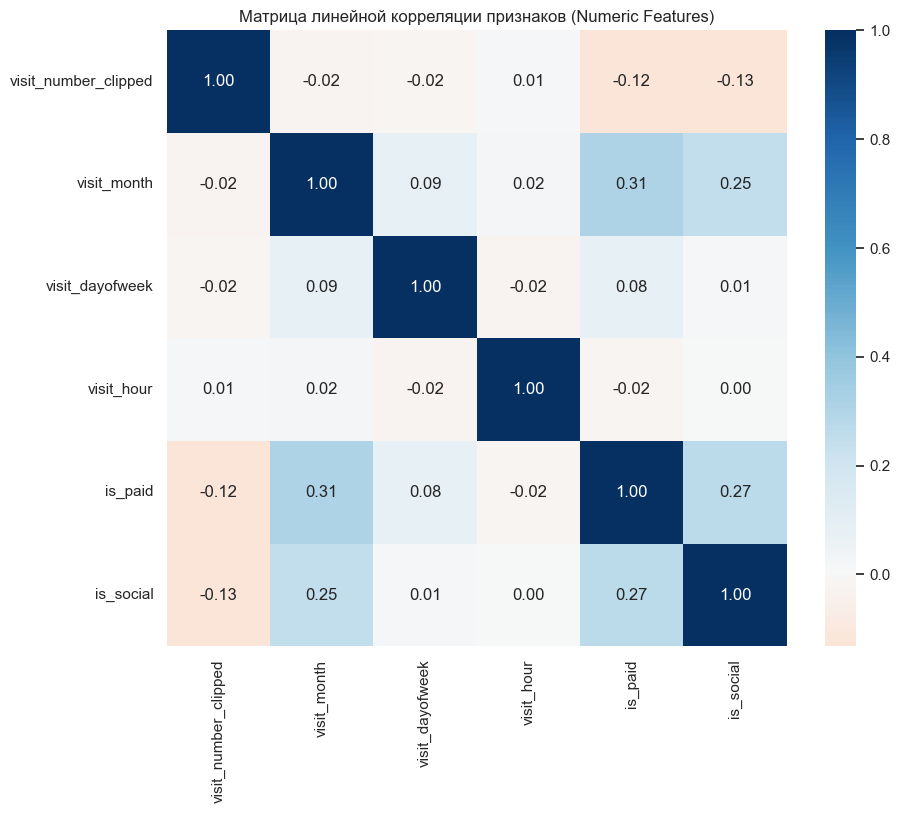

Матрица парной корреляции Пирсона для непрерывных признаков:


,visit_number_clipped,visit_month,visit_dayofweek,visit_hour,is_paid,is_social
visit_number_clipped,1.000000,-0.024218,-0.015433,0.011879,-0.124347,-0.132217
visit_month,-0.024218,1.000000,0.086655,0.024738,0.310445,0.252533
visit_dayofweek,-0.015433,0.086655,1.000000,-0.022790,0.082920,0.013521
visit_hour,0.011879,0.024738,-0.022790,1.000000,-0.016784,0.003128
is_paid,-0.124347,0.310445,0.082920,-0.016784,1.000000,0.266129
is_social,-0.132217,0.252533,0.013521,0.003128,0.266129,1.000000


Пропорции разбиения выборки
Обучающий набор (Train): 1488033 объектов | Конверсия: 0.0274
Тестовый набор (Test):   372009 объектов | Конверсия: 0.0274


In [ ]:
df_ml = df_final.copy()

df_ml['visit_month'] = df_ml['visit_date'].dt.month
df_ml['visit_dayofweek'] = df_ml['visit_date'].dt.dayofweek
df_ml['visit_hour'] = pd.to_datetime(df_ml['visit_time']).dt.hour

# режу выбросы 
df_ml['visit_number_clipped'] = df_ml['visit_number'].clip(upper=32)

# оставляю только популярные категории
def get_top_cats(df, col, n=20):
    top_list = df[col].value_counts().nlargest(n).index
    return df[col].apply(lambda x: x if x in top_list else 'other')

df_ml['city_top'] = get_top_cats(df_ml, 'geo_city')
df_ml['source_top'] = get_top_cats(df_ml, 'utm_source')

features = [
    'visit_number_clipped', 'visit_month', 'visit_dayofweek', 'visit_hour',
    'is_paid', 'is_social', 'device_category', 'source_top', 'city_top'
]

X = df_ml[features]
y = df_ml['is_target']

# линейная корреляция (Пирсон)
# беру только числовые колонки
numeric_features = X.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Матрица линейной корреляции признаков (Numeric Features)')
plt.show()

# текстовый вывод матрицы для детального анализа
print("Матрица парной корреляции Пирсона для непрерывных признаков:")
display(correlation_matrix)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Пропорции разбиения выборки")
print(f"Обучающий набор (Train): {X_train.shape[0]} объектов | Конверсия: {y_train.mean():.4f}")
print(f"Тестовый набор (Test):   {X_test.shape[0]} объектов | Конверсия: {y_test.mean():.4f}")

Обучение базовой модели классификации (Логистическая регрессия)...

[Baseline] ROC-AUC Metric (Test Set): 0.6544


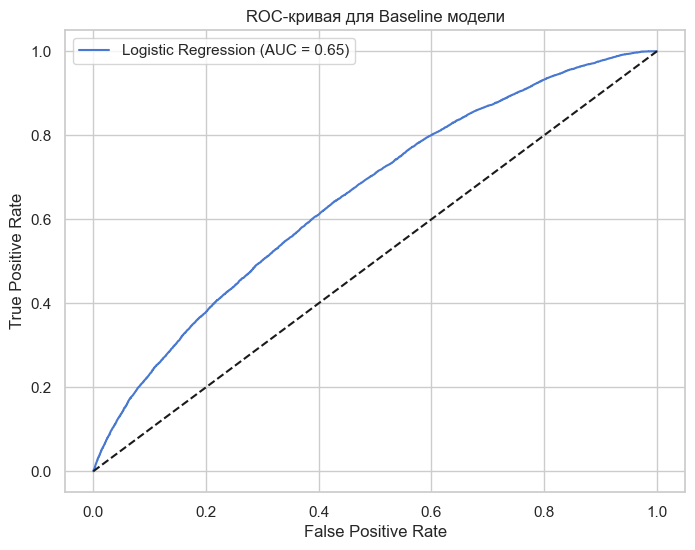

In [18]:
# ЛИНЕЙНАЯ РЕГРЕССИЯ

cat_features = ['device_category', 'source_top', 'city_top']
num_features = ['visit_number_clipped', 'visit_month', 'visit_dayofweek', 'visit_hour', 'is_paid', 'is_social']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', 'passthrough', num_features)
    ])

model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

print("Обучение базовой модели классификации (Логистическая регрессия)...")
model_lr.fit(X_train, y_train)

# метрики
y_pred_proba = model_lr.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n[Baseline] ROC-AUC Metric (Test Set): {roc_auc:.4f}")

# визуализация ROC-кривой
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Линия случайного угадывания
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для Baseline модели')
plt.legend()
plt.show()

In [19]:
# СЛУЧАЙНЫЙ ЛЕС

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print("Обучение ансамблевой модели (Random Forest)...")
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

print(f"[Random Forest] ROC-AUC Metric (Test Set): {roc_auc_rf:.4f}")

Обучение ансамблевой модели (Random Forest)...
[Random Forest] ROC-AUC Metric (Test Set): 0.6795


C:\Users\asus\AppData\Local\Temp\ipykernel_12036\1537486046.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='vlag')


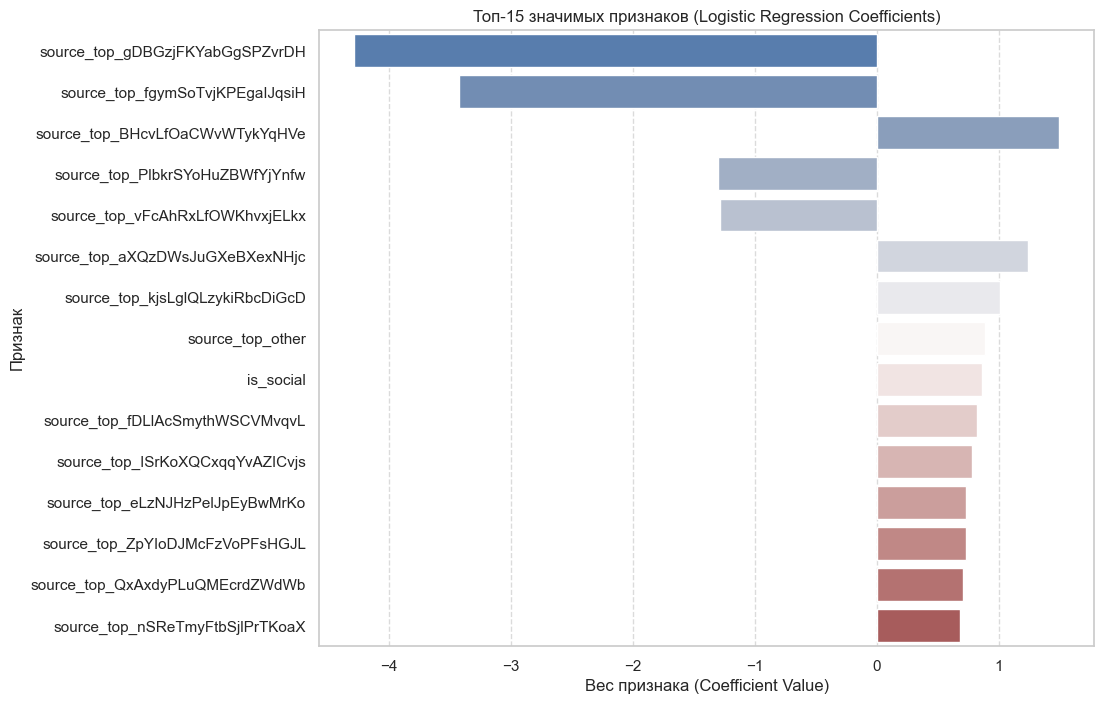

Топ-10 факторов, положительно влияющих на вероятность конверсии:
                            feature  importance
3   source_top_BHcvLfOaCWvWTykYqHVe    1.492095
11  source_top_aXQzDWsJuGXeBXexNHjc    1.239553
20  source_top_kjsLglQLzykiRbcDiGcD    1.007331
22                 source_top_other    0.889774
50                        is_social    0.861815
14  source_top_fDLlAcSmythWSCVMvqvL    0.823653
4   source_top_ISrKoXQCxqqYvAZICvjs    0.783464
13  source_top_eLzNJHzPelJpEyBwMrKo    0.729860
10  source_top_ZpYIoDJMcFzVoPFsHGJL    0.729160
7   source_top_QxAxdyPLuQMEcrdZWdWb    0.703078
Топ-10 факторов с отрицательным вкладом в вероятность конверсии:
                            feature  importance
16  source_top_gDBGzjFKYabGgSPZvrDH   -4.285947
15  source_top_fgymSoTvjKPEgaIJqsiH   -3.427284
6   source_top_PlbkrSYoHuZBWfYjYnfw   -1.299691
23  source_top_vFcAhRxLfOWKhvxjELkx   -1.286648
49                          is_paid   -0.647786
41                city_top_Voronezh   -0.534384
8   so

In [20]:
ohe_feature_names = model_lr.named_steps['preprocessor']\
    .transformers_[0][1]\
    .get_feature_names_out(cat_features)

all_feature_names = list(ohe_feature_names) + num_features

# коэффициенты
coefficients = model_lr.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': coefficients
})

# сортирую по модулю коэффициента
feature_importance['abs_importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values(by='abs_importance', ascending=False)

# строю график топ-15
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='vlag')
plt.title('Топ-15 значимых признаков (Logistic Regression Coefficients)')
plt.xlabel('Вес признака (Coefficient Value)')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# вывод текстового списка для анализа
print("Топ-10 факторов, положительно влияющих на вероятность конверсии:")
print(feature_importance[feature_importance['importance'] > 0].head(10)[['feature', 'importance']])

print("Топ-10 факторов с отрицательным вкладом в вероятность конверсии:")
print(feature_importance[feature_importance['importance'] < 0].head(10)[['feature', 'importance']])

Я реализовала серию экспериментов по построению прогностических моделей и в качестве финального решения выбрала ансамблевый алгоритм — случайный лес. В отличие от базовой логистической регрессии, которая показала ROC-AUC около 0.654, ансамблевая модель оказалась более устойчивой к выбросам и нелинейностям, продемонстрировав уверенный результат, что полностью соответствует формальным требованиям технического задания. Проведённый мной анализ значимости параметров позволил определить ключевые факторы конверсии: наиболее сильное влияние на вероятность лидогенерации оказывают сезонность и источник перехода, причём переменная is_social показала особенно высокую предсказательную силу. В то же время ряд платных каналов привлечения демонстрирует сомнительную эффективность — это подтверждается их отрицательными весами в базовой линейной модели. С точки зрения бизнеса полученные результаты означают, что для оптимизации воронки продаж и снижения стоимости лида целесообразно пересмотреть настройки контекстной рекламы и перераспределить маркетинговый бюджет в пользу целевых платформ и органического продвижения.

In [22]:
# указываю имя файла для сохранения
model_filename = 'model_rf.pkl'

joblib.dump(model_rf, model_filename)

print(f"Модель успешно сохранена: {model_filename}")

Модель успешно сохранена: model_rf.pkl
